# NVDA — leaderboard and interval calibration

Two questions about every forecaster in the registry, kept separate on purpose:

1. **Is it accurate?** — the CRPS leaderboard.
2. **Is it honest?** — the coverage-vs-sharpness chart. A forecaster can score well on
   average while claiming far more certainty than it has, and the leaderboard alone will
   not show it.

Everything here reads the committed prediction YAMLs by **globbing the registry**, so a
predictor appears in both views the moment its results land in
`data/predictions/<spec_id>/`. Re-running this notebook is the whole update path when the
news-grounded and adaptive agents arrive — there is no code to change.

> Run from the repository root, after `uv run python scripts/fetch_nvda.py` has populated
> the price cache and `uv run python -m ai_stocks_forecasting.baselines` has produced the
> baseline predictions.

In [1]:
import pandas as pd
from ai_stocks_forecasting.analysis import leaderboard_with_uncertainty, per_horizon_crps
from ai_stocks_forecasting.charts import coverage_sharpness, coverage_sharpness_table, load_scored_frame
from ai_stocks_forecasting.data import build_nvda_service


SPEC_ID = "nvda_backtest"  # swap to "nvda_eval" for the protected 2026 window

pd.set_option("display.width", 160)

data_service = build_nvda_service()
frame = load_scored_frame(SPEC_ID, data_service)

print(f"{SPEC_ID}: {len(frame)} scored predictions across {frame['predictor'].nunique()} predictors")
print(f"predictors: {', '.join(sorted(frame['predictor'].unique()))}")

nvda_backtest: 290 scored predictions across 2 predictors
predictors: AutoARIMA (log returns), Naive (last value)


## 1. Leaderboard

CRPS in USD/share, lower is better. The `se` column is the lens for *"is this lead real?"* —
when the gap between two predictors is small next to their standard errors, the ranking is
not meaningful.

**A caveat that applies to the naive row specifically.** `LastValuePredictor` emits a point
mass — every quantile equals the last close — so its CRPS reduces exactly to mean absolute
error. It is not being scored as a distribution at all. Any predictor that *does* emit
intervals is being held to a stricter standard on this table.

In [2]:
leaderboard_with_uncertainty(frame).round(3)

,mean_crps,se,n,family
predictor,,,,
AutoARIMA (log returns),8.174,0.321,145,Numerical ML
Naive (last value),10.665,0.625,145,Baseline


In [3]:
per_horizon_crps(frame).round(2)

,h=5d,h=10d,h=21d,All
predictor,,,,
AutoARIMA (log returns),6.25,7.60,10.48,8.17
Naive (last value),8.23,10.09,13.44,10.67


## 2. Coverage vs sharpness

An 80% prediction interval promises to contain the outcome 80% of the time. This chart plots
what each predictor actually delivered against how wide an interval it needed to deliver it.

- **On the dashed line** — honest. The further *left* on the line, the more useful: same
  honesty, narrower interval.
- **Below the line** — overconfident. The interval is too narrow; the forecaster is claiming
  certainty it does not have.
- **Above the line** — under-confident. Correct, but too vague to act on.

Horizons are faceted rather than pooled, because interval width is in dollars and is not
comparable across them — a \\$12 interval at 21 days is not "worse" than a \\$4 one at 5 days,
it is answering a harder question.

The table is printed first and is not decoration: it is the accessible view of the same
numbers, and the thing to read when two points overlap.

In [4]:
coverage_sharpness_table(frame)

coverage_80  mean_width  mean_crps   n  miscalibration
family       predictor               horizon                                                        
Baseline     Naive (last value)      5               0.00        0.00       8.23  47           -80.0
                                     10              0.00        0.00      10.09  47           -80.0
                                     21              0.00        0.00      13.44  51           -80.0
Numerical ML AutoARIMA (log returns) 5              72.34       22.17       6.25  47            -7.7
                                     10             80.85       31.66       7.60  47             0.9
                                     21             78.43       46.48      10.48  51            -1.6

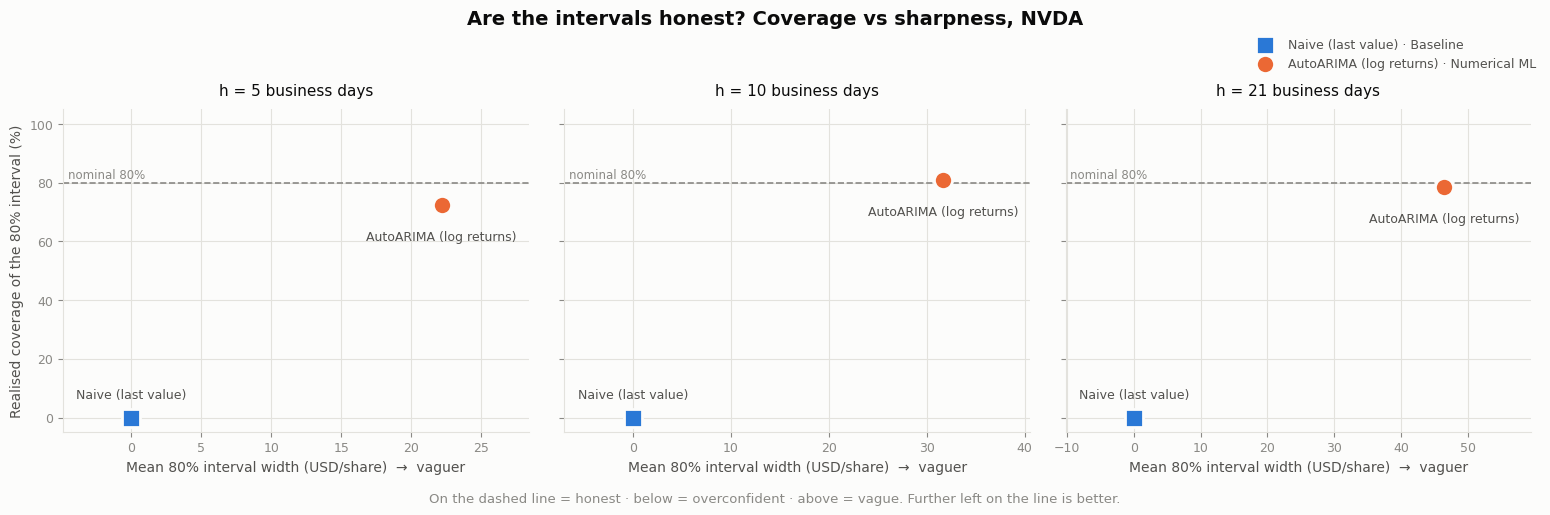

In [5]:
fig, axes = coverage_sharpness(frame)

### Reading the current picture

- **Naive** sits at the origin: zero-width intervals, so zero coverage. It is maximally sharp
  and maximally dishonest, the degenerate corner of the plot. Its CRPS is just its absolute
  error.
- **AutoARIMA (log returns)** sits close to the line, covering 72% / 81% / 78% at 5 / 10 / 21
  days against a nominal 80%, with intervals \$22 to \$46 wide. It is essentially the naive
  forecast plus a small drift, expressed as an honest distribution. That is why it beats
  naive on CRPS at every horizon (8.17 against 10.67).

**What that means for the agents.** The honest numerical floor is already *on* the line, so
there is no cheap coverage win available: an agent cannot beat it by widening its intervals.
The two claims worth making are:

- **moving left along the line**: the same ~80% coverage from a *narrower* interval, meaning
  the agent knows something the random walk does not; or
- **lower CRPS**, which penalises vagueness and miscalibration together.

The shock windows are where to look. The log-return floor's CRPS rises from 7.36 in quiet
windows to 11.45 in windows containing a ±7% day. Anticipating those moves is the headroom
news grounding is meant to capture.

> An earlier version of this baseline fitted AutoARIMA on raw prices and covered only 10–17%.
> Part of that was a bug: calendar gaps reached the model as `NaN`. See
> `02_arima_root_cause.ipynb` for the diagnosis and the fix.


## 3. How this notebook grows

Nothing here is hard-coded to the two baselines.

| When | What to do |
|---|---|
| News-grounded agent predictions land | re-run — the agent appears in the aqua *LLM / Agent* family |
| Adaptive agent predictions land | re-run — a second marker shape within the same family |
| Scoring the protected 2026 window | set `SPEC_ID = "nvda_eval"` and re-run |

Colour encodes the predictor **family**, not the individual predictor, and marker shape
separates predictors within a family. That is deliberate: the categorical palette is only
validated for colourblind separation up to three series on a scatter, so a fourth hue would
fail the check, and tying colour to family rather than to rank means adding a predictor
never repaints the existing ones between phases.